In [1]:
from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

In [6]:
sb = fits.open('Halpha_moment0.fits')[0].data.astype(float)
cont = fits.open('Halpha_continuum_map.fits')[0].data.astype(float)

In [7]:
m = ~np.isfinite(cont) | (cont < 0.0)
cont[m] = 0.0
cont   /= cont.max()

In [8]:

m = ~np.isfinite(sb) | (sb < 0.0)
sb[m] = 0.0
sb   /= sb.max()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\2615405604.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\2615405604.py:9: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow( np.log10(cont), **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\2615405604.py:12: RuntimeWarning: divide by zero encountered in log10
  im = axx.imshow( np.log10(sb), **imshow_kwds2)


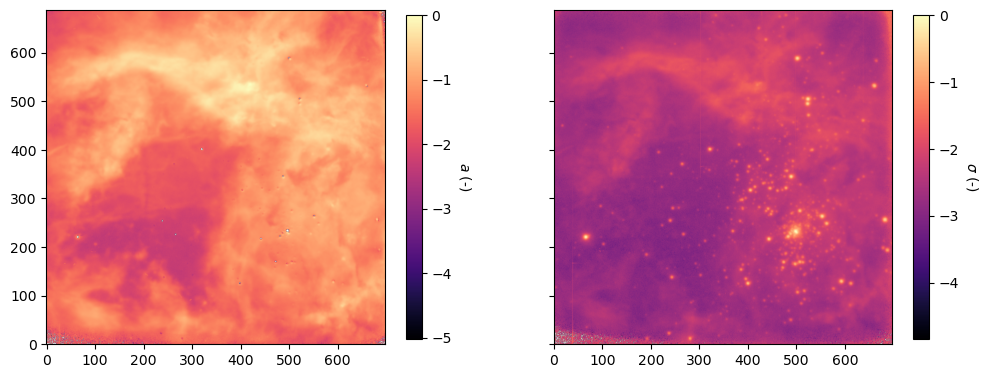

In [11]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( np.log10(cont), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow( np.log10(sb), **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
#fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\23084508.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\23084508.py:9: RuntimeWarning: divide by zero encountered in divide
  im = ax.imshow( np.log10(sb/cont), **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\23084508.py:9: RuntimeWarning: invalid value encountered in divide
  im = ax.imshow( np.log10(sb/cont), **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\23084508.py:9: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow( np.log10(sb/cont), **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\23084508.py:12: RuntimeWarning: divide by zero encountered in divide
  im = axx.imshow(np.log10(cont/sb), **imshow_kwds2)
C:\Users\javas\AppData\Local\Temp\ipykernel_4290

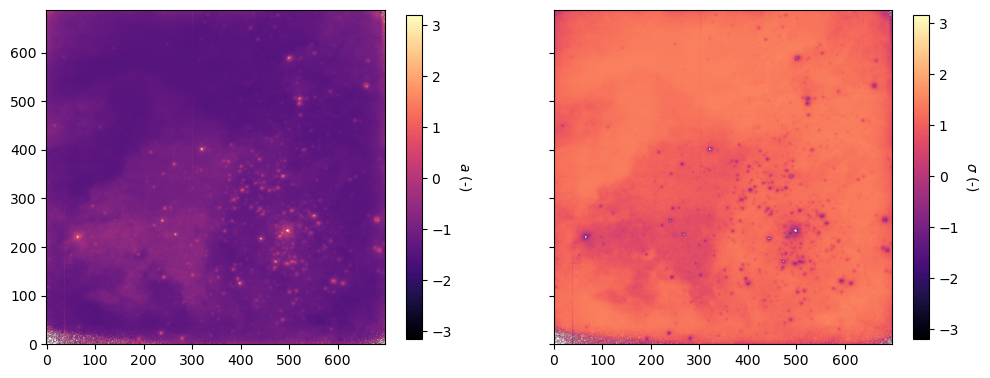

In [12]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( np.log10(sb/cont), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(np.log10(cont/sb), **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
#fig.suptitle(line, y=0.8)

In [18]:
cont_m = sb/cont

C:\Users\javas\AppData\Local\Temp\ipykernel_42900\3942693825.py:1: RuntimeWarning: divide by zero encountered in divide
  cont_m = sb/cont
C:\Users\javas\AppData\Local\Temp\ipykernel_42900\3942693825.py:1: RuntimeWarning: invalid value encountered in divide
  cont_m = sb/cont


In [19]:
m = ~np.isfinite(cont_m) | (cont_m < 0.5)
cont_m[m] = 0.0
#cont_sub   /= cont_sub.max()

In [20]:
mask_cont=cont_sub.astype(bool)

In [22]:
sb_m1 = np.where(mask_cont, sb, np.nan)

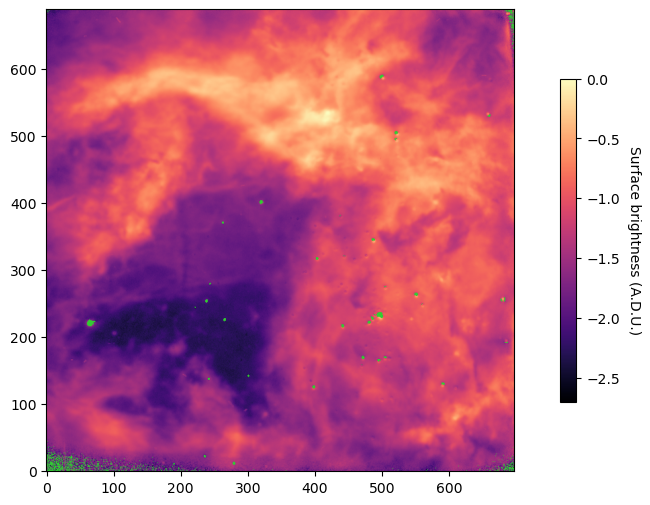

In [23]:
fig, (axx) = plt.subplots(
    1,
    1,
    sharey=True,
    figsize=(12, 6),
)
#imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
#im = ax.imshow(vv,vmin = 120, vmax=220,**imshow_kwds)
#im.cmap.set_bad(color='gray')
#cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
#cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(sb_m1), **imshow_kwds2)
im.cmap.set_bad(color='limegreen')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [24]:
hdu_mk = fits.ImageHDU(data=mask_cont.astype(np.uint8) ,  name='MASK')
primary = fits.PrimaryHDU()
hdul = fits.HDUList([primary, hdu_mk])
hdul.writeto('fits_ready/mask_cont.fits', overwrite=True)